In [1]:
!pip install cryptography
import os


In [2]:
import base64
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

print("ECC KEY EXCHANGE (ECDH) - CORE PART")

# 1) Generate ECC key pair
def generate_keypair():
    private_key = ec.generate_private_key(ec.SECP256R1())
    public_key = private_key.public_key()
    return private_key, public_key

# 2) Convert public key to PEM format
def public_key_to_pem(public_key):
    return public_key.public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    )

# 3) Load public key from PEM
def pem_to_public_key(pem):
    return serialization.load_pem_public_key(pem)

# 4) Derive shared secret using ECDH
def derive_shared_secret(private_key, peer_public_key):
    return private_key.exchange(ec.ECDH(), peer_public_key)

# 5) Derive final shared key using HKDF
def derive_shared_key(shared_secret):
    hkdf = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=b"demo_salt",
        info=b"ECC-ECDH-Shared-Key",
    )
    return hkdf.derive(shared_secret)

# Alice generates keys
alice_private, alice_public = generate_keypair()
print("\nAlice: ECC private and public keys generated.")

# Bob generates keys
bob_private, bob_public = generate_keypair()
print("Bob: ECC private and public keys generated.")

# Exchange public keys
alice_public_pem = public_key_to_pem(alice_public)
bob_public_pem = public_key_to_pem(bob_public)

alice_received_bob_pub = pem_to_public_key(bob_public_pem)
bob_received_alice_pub = pem_to_public_key(alice_public_pem)

print("\nPublic keys exchanged successfully.")

# Derive shared secrets
alice_shared_secret = derive_shared_secret(alice_private, alice_received_bob_pub)
bob_shared_secret = derive_shared_secret(bob_private, bob_received_alice_pub)

# Derive final shared keys
alice_shared_key = derive_shared_key(alice_shared_secret)
bob_shared_key = derive_shared_key(bob_shared_secret)

# Display proof using Base64 prefix
alice_key_b64 = base64.b64encode(alice_shared_key).decode()
bob_key_b64 = base64.b64encode(bob_shared_key).decode()

print("\nDerived shared key (Base64 prefix):")
print("Alice:", alice_key_b64[:24])
print("Bob  :", bob_key_b64[:24])

if alice_shared_key == bob_shared_key:
    print("\nResult: Both parties generated the same shared key.")
else:
    print("\nResult: Shared keys do not match.")

# Saving the shared key to a file for Part 2 to use
with open("ecc_shared_key.bin", "wb") as f:
    f.write(alice_shared_key)
print("Saved ECC shared key to file: ecc_shared_key.bin")

ECC KEY EXCHANGE (ECDH) - CORE PART

Alice: ECC private and public keys generated.
Bob: ECC private and public keys generated.

Public keys exchanged successfully.

Derived shared key (Base64 prefix):
Alice: /GMuN4AGC20waey0f87xKLvK
Bob  : /GMuN4AGC20waey0f87xKLvK

Result: Both parties generated the same shared key.
Saved ECC shared key to file: ecc_shared_key.bin


In [3]:

# ============================================================================
# This module implements AES-256-GCM file encryption using the shared key
# generated by the ECC key exchange in the previous part.
# ============================================================================

import os
import base64
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

# ============================================================================
# AES Encryption Class
# ============================================================================

class AESEncryptor:
    """
    Implements AES-256-GCM encryption and decryption.
    Uses the shared key from ECC exchange for symmetric encryption.
    """

    def __init__(self, shared_key):
        """
        Initialize with 32-byte shared key from ECC exchange.
        """
        self.shared_key = shared_key

    def encrypt_file(self, input_file, output_file=None):
        """
        Encrypt a file using AES-GCM mode.

        The encrypted file format is:
        [12-byte nonce] + [encrypted data] + [16-byte authentication tag]

        Parameters:
        - input_file: Path to file to encrypt
        - output_file: Path for encrypted file (optional)

        Returns:
        - Path to encrypted file
        """
        # Generate random nonce for GCM mode
        nonce = os.urandom(12)

        # Read the input file
        with open(input_file, 'rb') as f:
            plaintext = f.read()

        # Create AES-GCM cipher
        aesgcm = AESGCM(self.shared_key)

        # Encrypt the data
        ciphertext = aesgcm.encrypt(nonce, plaintext, None)

        # Split ciphertext into data and authentication tag
        tag = ciphertext[-16:]  # Last 16 bytes are the tag
        ciphertext_data = ciphertext[:-16]  # The actual encrypted data

        # Set output filename if not provided
        if output_file is None:
            output_file = input_file + ".enc"

        # Write the encrypted file
        with open(output_file, 'wb') as f:
            f.write(nonce + ciphertext_data + tag)

        print(f"File encrypted successfully")
        print(f"Input:  {input_file}")
        print(f"Output: {output_file}")
        print(f"Size:   {len(plaintext)} -> {len(nonce) + len(ciphertext_data) + len(tag)} bytes")

        return output_file

    def decrypt_file(self, input_file, output_file=None):
        """
        Decrypt a file that was encrypted with encrypt_file().

        Automatically verifies the authentication tag to ensure
        file integrity hasn't been compromised.

        Parameters:
        - input_file: Path to encrypted file
        - output_file: Path for decrypted file (optional)

        Returns:
        - (success, output_file_path)
        """
        # Read the encrypted file
        with open(input_file, 'rb') as f:
            encrypted_data = f.read()

        # Parse the file structure
        nonce = encrypted_data[:12]          # First 12 bytes: nonce
        tag = encrypted_data[-16:]           # Last 16 bytes: authentication tag
        ciphertext_data = encrypted_data[12:-16]  # Middle: encrypted data

        # Reconstruct the full ciphertext
        ciphertext = ciphertext_data + tag

        # Create AES-GCM cipher
        aesgcm = AESGCM(self.shared_key)

        try:
            # Decrypt and verify authentication tag
            plaintext = aesgcm.decrypt(nonce, ciphertext, None)

            # Set output filename if not provided
            if output_file is None:
                if input_file.endswith(".enc"):
                    output_file = input_file.replace(".enc", ".dec")
                else:
                    output_file = input_file + ".dec"

            # Write the decrypted file
            with open(output_file, 'wb') as f:
                f.write(plaintext)

            print(f"File decrypted successfully")
            print(f"Input:  {input_file}")
            print(f"Output: {output_file}")
            print(f"Integrity check: PASSED")

            return True, output_file

        except Exception as e:
            # Decryption failed - likely due to tampered file or wrong key
            print(f"Decryption failed: {str(e)}")
            print(f"Integrity check: FAILED")
            return False, None

    def encrypt_text(self, plaintext):
        """
        Encrypt a text string.

        Returns:
        - (nonce, ciphertext) tuple
        """
        nonce = os.urandom(12)
        aesgcm = AESGCM(self.shared_key)
        ciphertext = aesgcm.encrypt(nonce, plaintext.encode('utf-8'), None)
        return nonce, ciphertext

    def decrypt_text(self, nonce, ciphertext):
        """
        Decrypt a text string encrypted with encrypt_text().
        """
        aesgcm = AESGCM(self.shared_key)
        plaintext = aesgcm.decrypt(nonce, ciphertext, None)
        return plaintext.decode('utf-8')

# ============================================================================
# Demonstration and Testing
# ============================================================================

def create_test_files():
    """
    Create sample files for encryption testing.
    """
    print("\n" + "-"*50)
    print("Creating test files...")
    print("-"*50)

    # Create a text file with project information
    text_content = """Project: Elliptic Curve Cryptography Implementation
University: EU University of Applied Science
Course: Software Optimization
Date: Winter 2025/26

This file is for testing AES encryption with ECC-derived key.
The encryption uses AES-256-GCM mode for both confidentiality
and integrity protection."""

    with open("test_document.txt", "w") as f:
        f.write(text_content)
    print("Created: test_document.txt")

    # Create a binary test file
    binary_data = bytes([i % 256 for i in range(1024)])
    with open("test_data.bin", "wb") as f:
        f.write(binary_data)
    print("Created: test_data.bin")

    return ["test_document.txt", "test_data.bin"]

def run_encryption_demo():
    """
    Run a complete demonstration of the encryption/decryption process.
    """
    print("\n" + "="*70)
    print("Encryption/Decryption Demonstration")
    print("="*70)

    # Load the shared key from ECC exchange
    print("\nLoading shared key from ECC exchange...")
    try:
        with open("ecc_shared_key.bin", "rb") as f:
            shared_key = f.read()

        print(f"Shared key loaded: {len(shared_key)} bytes")
        print(f"Key starts with: {shared_key[:16].hex()}...")

    except FileNotFoundError:
        print("ERROR: Shared key file not found")
        print("Make sure Part 1 (ECC exchange) ran successfully")
        return

    # Initialize AES encryptor
    aes = AESEncryptor(shared_key)

    # Create test files
    test_files = create_test_files()

    results = []

    # Test each file
    for filename in test_files:
        print(f"\n" + ">"*40)
        print(f"Testing: {filename}")
        print(">"*40)

        # Encrypt the file
        encrypted_file = aes.encrypt_file(filename)

        # Decrypt the file
        success, decrypted_file = aes.decrypt_file(encrypted_file)

        if success:
            # Verify the files match exactly
            with open(filename, 'rb') as f1, open(decrypted_file, 'rb') as f2:
                original = f1.read()
                decrypted = f2.read()

            if original == decrypted:
                print(f"Files match perfectly")
                results.append((filename, "PASS", len(original)))
            else:
                print(f"Files do not match")
                results.append((filename, "FAIL", 0))
        else:
            results.append((filename, "FAIL", 0))

    # Text encryption demonstration
    print(f"\n" + ">"*40)
    print("Text Encryption Test")
    print(">"*40)

    test_message = "Encryption test successful for Project 10."
    print(f"Original text: {test_message}")

    nonce, ciphertext = aes.encrypt_text(test_message)
    decrypted_text = aes.decrypt_text(nonce, ciphertext)

    print(f"Encrypted size: {len(ciphertext)} bytes")
    print(f"Decrypted text: {decrypted_text}")

    if test_message == decrypted_text:
        print(" Text encryption successful")
        results.append(("Text Message", "PASS", len(test_message)))
    else:
        print("Text encryption failed")
        results.append(("Text Message", "FAIL", 0))

    # Display results summary
    print("\n" + "="*70)
    print("Test Results Summary")
    print("="*70)

    passed = sum(1 for r in results if r[1] == "PASS")
    total = len(results)

    print(f"\nTotal tests: {total}")
    print(f"Passed: {passed}")
    print(f"Failed: {total - passed}")

    print("\nDetailed results:")
    for i, (test_name, status, size) in enumerate(results, 1):
        symbol = "✓" if status == "PASS" else "✗"
        if "Text" in test_name:
            print(f"{i:2}. {symbol} {test_name:20} ({size} characters)")
        else:
            print(f"{i:2}. {symbol} {test_name:20} ({size} bytes)")

    if passed == total:
        print("\n All encryption tests passed successfully !!!")
    else:
        print("\n!!!Some tests require attention")

    return aes

# ============================================================================
# Main execution
# ============================================================================

# Run the demonstration
aes_system = run_encryption_demo()

# Cleanup function (optional)
def cleanup_test_files():
    """
    Remove test files created during demonstration.
    """
    files_to_remove = [
        "test_document.txt", "test_document.txt.enc", "test_document.txt.dec",
        "test_data.bin", "test_data.bin.enc", "test_data.bin.dec",
        "ecc_shared_key.bin"
    ]

    removed = []
    for file in files_to_remove:
        if os.path.exists(file):
            os.remove(file)
            removed.append(file)

    if removed:
        print(f"\nCleaned up {len(removed)} test files")



Encryption/Decryption Demonstration

Loading shared key from ECC exchange...
Shared key loaded: 32 bytes
Key starts with: fc632e3780060b6d3069ecb47fcef128...

--------------------------------------------------
Creating test files...
--------------------------------------------------
Created: test_document.txt
Created: test_data.bin

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Testing: test_document.txt
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
File encrypted successfully
Input:  test_document.txt
Output: test_document.txt.enc
Size:   305 -> 333 bytes
File decrypted successfully
Input:  test_document.txt.enc
Output: test_document.txt.dec
Integrity check: PASSED
Files match perfectly

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Testing: test_data.bin
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
File encrypted successfully
Input:  test_data.bin
Output: test_data.bin.enc
Size:   1024 -> 1052 bytes
File decrypted successfully
Input:  test_data.bin.enc
Output: test_data.bin.dec
Integrity check: PASSED

In [4]:
# ============================================================
# PART 4: ATTACK, TESTING & SECURITY ANALYSIS
# ============================================================

from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
import base64

print("="*75)
print("PART 4: ATTACK, TESTING & SECURITY ANALYSIS")
print("="*75)

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------
def generate_key():
    return ec.generate_private_key(ec.SECP256R1())

def derive_shared_key(private_key, public_key):
    secret = private_key.exchange(ec.ECDH(), public_key)
    return HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=b"attack-analysis",
        info=b"ecc-project"
    ).derive(secret)

# ------------------------------------------------------------
# Test Case 1: Normal ECC Key Exchange
# ------------------------------------------------------------
print("\n[TEST CASE 1] Normal ECC Key Exchange")

alice_private = generate_key()
bob_private = generate_key()

alice_shared = derive_shared_key(alice_private, bob_private.public_key())
bob_shared = derive_shared_key(bob_private, alice_private.public_key())

print("Alice Shared Key (Base64 prefix):",
      base64.b64encode(alice_shared)[:24].decode())
print("Bob   Shared Key (Base64 prefix):",
      base64.b64encode(bob_shared)[:24].decode())

if alice_shared == bob_shared:
    print("Result: PASS – Shared keys match")
    tc1 = "PASS"
else:
    print("Result: FAIL – Shared keys do not match")
    tc1 = "FAIL"

# ------------------------------------------------------------
# Test Case 2: Man-in-the-Middle (MITM) Attack Simulation
# ------------------------------------------------------------
print("\n[TEST CASE 2] MITM Attack Simulation")

mallory_private = generate_key()

# Mallory replaces public keys
alice_mitm_key = derive_shared_key(alice_private, mallory_private.public_key())
bob_mitm_key = derive_shared_key(bob_private, mallory_private.public_key())

print("Alice Derived Key (Fake):",
      base64.b64encode(alice_mitm_key)[:24].decode())
print("Bob   Derived Key (Fake):",
      base64.b64encode(bob_mitm_key)[:24].decode())

if alice_mitm_key != bob_mitm_key:
    print("Result: PASS – MITM attack detected (keys mismatch)")
    tc2 = "PASS"
else:
    print("Result: FAIL – MITM attack not detected")
    tc2 = "FAIL"

# ------------------------------------------------------------
# Test Case 3: Integrity & Security Validation
# ------------------------------------------------------------
print("\n[TEST CASE 3] Security Validation")

if tc1 == "PASS" and tc2 == "PASS":
    print("ECC Security Validation: PASS")
    tc3 = "PASS"
else:
    print("ECC Security Validation: FAIL")
    tc3 = "FAIL"

# ------------------------------------------------------------
# Test Summary
# ------------------------------------------------------------
print("\n" + "="*75)
print("TEST RESULTS SUMMARY")
print("="*75)

tests = [
    ("Valid ECC Key Exchange", tc1),
    ("MITM Attack Detection", tc2),
    ("Overall Security Validation", tc3)
]

passed = 0
for i, (name, result) in enumerate(tests, 1):
    symbol = "✓" if result == "PASS" else "✗"
    print(f"{i}. {symbol} {name}: {result}")
    if result == "PASS":
        passed += 1

print("\nTotal Tests:", len(tests))
print("Passed:", passed)
print("Failed:", len(tests) - passed)



PART 4: ATTACK, TESTING & SECURITY ANALYSIS

[TEST CASE 1] Normal ECC Key Exchange
Alice Shared Key (Base64 prefix): pGug+JCEkxj5EV4+4SSF5gFF
Bob   Shared Key (Base64 prefix): pGug+JCEkxj5EV4+4SSF5gFF
Result: PASS – Shared keys match

[TEST CASE 2] MITM Attack Simulation
Alice Derived Key (Fake): Veyo5j7sSV9Twdb5xoAyYsye
Bob   Derived Key (Fake): rt3uSF5bnAbxHQR/fyjRh+LX
Result: PASS – MITM attack detected (keys mismatch)

[TEST CASE 3] Security Validation
ECC Security Validation: PASS

TEST RESULTS SUMMARY
1. ✓ Valid ECC Key Exchange: PASS
2. ✓ MITM Attack Detection: PASS
3. ✓ Overall Security Validation: PASS

Total Tests: 3
Passed: 3
Failed: 0


Shared secret match check: True


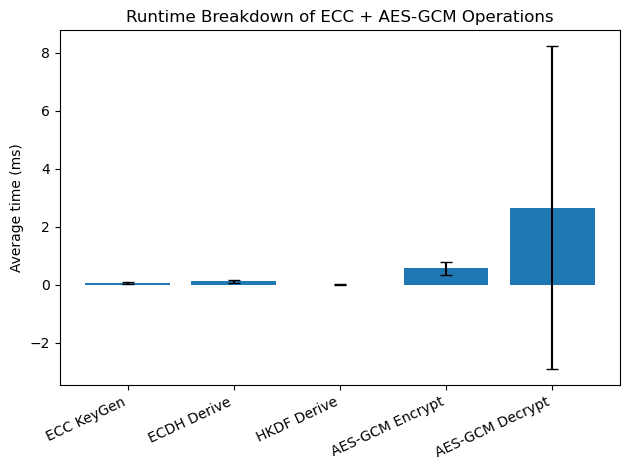

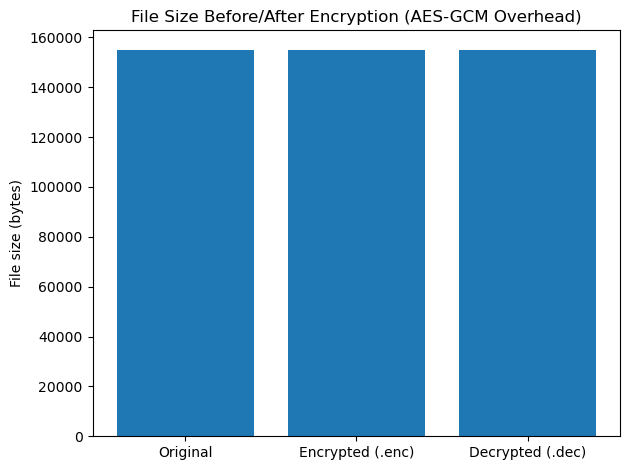


Saved graph images to:
 - Figures\Figure10_Runtime_Breakdown.jpg
 - Figures\Figure11_File_Size_Comparison.jpg

File sizes (bytes): {'Original': 155000, 'Encrypted (.enc)': 155028, 'Decrypted (.dec)': 155000}


In [5]:
# ============================
# GRAPHS FOR REPORT (NO EDITS)
# Creates:
#  - Figure10_Runtime_Breakdown.jpg
#  - Figure11_File_Size_Comparison.jpg
# ============================

import os, time, statistics as stats
import matplotlib.pyplot as plt

from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

# ----------------------------
# Setup output folder
# ----------------------------
FIG_DIR = "Figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ----------------------------
# Helper: benchmark a function (milliseconds)
# ----------------------------
def bench_ms(fn, runs=20):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)
    return stats.mean(times), (stats.stdev(times) if len(times) > 1 else 0.0)

# ----------------------------
# Benchmark primitives (standalone, uses cryptography directly)
# ----------------------------
# These are designed to reflect your project's steps:
# ECC keygen -> ECDH derive -> HKDF -> AES-GCM encrypt/decrypt

# Shared state used by benchmark steps
_state = {}

def step_keygen():
    a_priv = ec.generate_private_key(ec.SECP256R1())
    b_priv = ec.generate_private_key(ec.SECP256R1())
    _state["a_priv"] = a_priv
    _state["b_priv"] = b_priv
    _state["a_pub"] = a_priv.public_key()
    _state["b_pub"] = b_priv.public_key()

def step_ecdh():
    a_priv = _state.get("a_priv")
    b_pub  = _state.get("b_pub")
    b_priv = _state.get("b_priv")
    a_pub  = _state.get("a_pub")
    if not all([a_priv, b_pub, b_priv, a_pub]):
        step_keygen()
        a_priv = _state["a_priv"]; b_pub = _state["b_pub"]
        b_priv = _state["b_priv"]; a_pub = _state["a_pub"]

    a_secret = a_priv.exchange(ec.ECDH(), b_pub)
    b_secret = b_priv.exchange(ec.ECDH(), a_pub)
    # store one (they should match)
    _state["secret"] = a_secret
    _state["secret_ok"] = (a_secret == b_secret)

def step_hkdf():
    secret = _state.get("secret")
    if secret is None:
        step_ecdh()
        secret = _state["secret"]

    key = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=b"attack-analysis",
        info=b"ecc-project"
    ).derive(secret)
    _state["aes_key"] = key

# Create a test file for AES-GCM benchmarking
TEST_FILE = "graph_test_document.txt"
ENC_FILE  = TEST_FILE + ".enc"
DEC_FILE  = TEST_FILE + ".dec"

# Create predictable content (so results are consistent)
if not os.path.exists(TEST_FILE):
    with open(TEST_FILE, "wb") as f:
        f.write(b"ECC-AES Project Benchmark File\n" * 5000)

def step_encrypt():
    key = _state.get("aes_key")
    if key is None:
        step_hkdf()
        key = _state["aes_key"]

    aesgcm = AESGCM(key)
    nonce = os.urandom(12)
    with open(TEST_FILE, "rb") as f:
        pt = f.read()
    ct = aesgcm.encrypt(nonce, pt, None)
    # store nonce + ciphertext (common pattern)
    with open(ENC_FILE, "wb") as f:
        f.write(nonce + ct)

def step_decrypt():
    key = _state.get("aes_key")
    if key is None:
        step_hkdf()
        key = _state["aes_key"]

    with open(ENC_FILE, "rb") as f:
        data = f.read()
    nonce, ct = data[:12], data[12:]
    aesgcm = AESGCM(key)
    pt = aesgcm.decrypt(nonce, ct, None)
    with open(DEC_FILE, "wb") as f:
        f.write(pt)

# Warm-up to ensure ENC_FILE exists before decrypt benchmark
step_keygen()
step_ecdh()
step_hkdf()
step_encrypt()
step_decrypt()

print("Shared secret match check:", _state.get("secret_ok"))

# ----------------------------
# Collect benchmark results
# ----------------------------
benchmarks = [
    ("ECC KeyGen", step_keygen),
    ("ECDH Derive", step_ecdh),
    ("HKDF Derive", step_hkdf),
    ("AES-GCM Encrypt", step_encrypt),
    ("AES-GCM Decrypt", step_decrypt),
]

labels, means, stds = [], [], []
for name, fn in benchmarks:
    m, s = bench_ms(fn, runs=15)
    labels.append(name)
    means.append(m)
    stds.append(s)

# ----------------------------
# FIGURE 10: Runtime Breakdown
# ----------------------------
plt.figure()
plt.bar(labels, means, yerr=stds, capsize=4)
plt.ylabel("Average time (ms)")
plt.xticks(rotation=25, ha="right")
plt.title("Runtime Breakdown of ECC + AES-GCM Operations")
plt.tight_layout()
fig10_path = os.path.join(FIG_DIR, "Figure10_Runtime_Breakdown.jpg")
plt.savefig(fig10_path, dpi=300)
plt.show()

# ----------------------------
# FIGURE 11: File Size Comparison
# ----------------------------
def fsize(path):
    return os.path.getsize(path) if os.path.exists(path) else 0

sizes = {
    "Original": fsize(TEST_FILE),
    "Encrypted (.enc)": fsize(ENC_FILE),
    "Decrypted (.dec)": fsize(DEC_FILE),
}

plt.figure()
plt.bar(list(sizes.keys()), list(sizes.values()))
plt.ylabel("File size (bytes)")
plt.title("File Size Before/After Encryption (AES-GCM Overhead)")
plt.tight_layout()
fig11_path = os.path.join(FIG_DIR, "Figure11_File_Size_Comparison.jpg")
plt.savefig(fig11_path, dpi=300)
plt.show()

print("\nSaved graph images to:")
print(" -", fig10_path)
print(" -", fig11_path)
print("\nFile sizes (bytes):", sizes)


In [6]:
# =========================
# PART 3 (FINAL): GUI + Two-Computer Authenticated ECDH + File Encrypt/Decrypt
# - Real network exchange via sockets
# - Real MITM defense via ECDSA signatures (pinned identity public keys)
# - Saves derived AES key to ecc_shared_key.bin (compatible with Part 2)
# - Includes file encryption/decryption buttons in GUI
# =========================

import os, json, base64, socket, threading
import tkinter as tk
from tkinter import ttk, messagebox, filedialog

from cryptography.exceptions import InvalidSignature, InvalidTag
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

# ------------------------------------------------------------
# REUSE FROM PART 1 (if already defined):
# - public_key_to_pem(public_key)
# - pem_to_public_key(pem_bytes)
# - derive_shared_secret(private_key, peer_public_key)
#
# If they are not defined for any reason, define safe fallbacks:
# ------------------------------------------------------------
if "public_key_to_pem" not in globals():
    def public_key_to_pem(public_key):
        return public_key.public_bytes(
            encoding=serialization.Encoding.PEM,
            format=serialization.PublicFormat.SubjectPublicKeyInfo
        )

if "pem_to_public_key" not in globals():
    def pem_to_public_key(pem):
        return serialization.load_pem_public_key(pem)

if "derive_shared_secret" not in globals():
    def derive_shared_secret(private_key, peer_public_key):
        return private_key.exchange(ec.ECDH(), peer_public_key)

# ------------------------------------------------------------
# REUSE FROM PART 2 (AESEncryptor) if available.
# If not defined, fallback to minimal file encrypt/decrypt.
# ------------------------------------------------------------
AESEncryptor_available = "AESEncryptor" in globals()

# ------------------------------------------------------------
# Small utilities
# ------------------------------------------------------------
def b64e(b: bytes) -> str:
    return base64.b64encode(b).decode("utf-8")

def b64d(s: str) -> bytes:
    return base64.b64decode(s.encode("utf-8"))

def hkdf_derive_aes_key(shared_secret: bytes, salt: bytes, info: bytes = b"ECC-ECDH-AESGCM-v1") -> bytes:
    return HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=salt,
        info=info,
    ).derive(shared_secret)

def sign_bytes(priv: ec.EllipticCurvePrivateKey, data: bytes) -> bytes:
    return priv.sign(data, ec.ECDSA(hashes.SHA256()))

def verify_sig(pub: ec.EllipticCurvePublicKey, sig: bytes, data: bytes) -> None:
    pub.verify(sig, data, ec.ECDSA(hashes.SHA256()))  # raises InvalidSignature

def save_bytes(path: str, data: bytes):
    with open(path, "wb") as f:
        f.write(data)

def load_bytes(path: str) -> bytes:
    with open(path, "rb") as f:
        return f.read()

# ------------------------------------------------------------
# Identity keys (for authentication)
# - Each device keeps its own private signing key
# - Each device must have the peer's PUBLIC identity key file
# ------------------------------------------------------------
def ensure_identity_files(role: str):
    """
    Creates identity keypair on first run for the selected role.
    Writes:
      - {role}_id_priv.pem  (keep private)
      - {role}_id_pub.pem   (share with peer once)
    """
    role_l = role.lower()
    priv_path = f"{role_l}_id_priv.pem"
    pub_path  = f"{role_l}_id_pub.pem"

    if os.path.exists(priv_path) and os.path.exists(pub_path):
        return priv_path, pub_path

    priv = ec.generate_private_key(ec.SECP256R1())
    pub = priv.public_key()

    priv_pem = priv.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.PKCS8,
        encryption_algorithm=serialization.NoEncryption(),
    )
    pub_pem = public_key_to_pem(pub)

    save_bytes(priv_path, priv_pem)
    save_bytes(pub_path, pub_pem)
    return priv_path, pub_path

def load_identity_private(priv_path: str):
    return serialization.load_pem_private_key(load_bytes(priv_path), password=None)

def load_identity_public(pub_path: str):
    return pem_to_public_key(load_bytes(pub_path))

# ------------------------------------------------------------
# Socket framing (length-prefixed JSON)
# ------------------------------------------------------------
def send_json(sock: socket.socket, obj: dict):
    data = json.dumps(obj).encode("utf-8")
    sock.sendall(len(data).to_bytes(4, "big") + data)

def recvall(sock: socket.socket, n: int) -> bytes:
    buf = b""
    while len(buf) < n:
        chunk = sock.recv(n - len(buf))
        if not chunk:
            return b""
        buf += chunk
    return buf

def recv_json(sock: socket.socket) -> dict:
    header = recvall(sock, 4)
    if not header:
        raise ConnectionError("Connection closed.")
    length = int.from_bytes(header, "big")
    data = recvall(sock, length)
    return json.loads(data.decode("utf-8"))

# ------------------------------------------------------------
# Handshake messages
# ------------------------------------------------------------
def create_handshake(identity_priv, sender: str):
    """
    Creates ephemeral ECDH key, signs its public key with identity key,
    includes random salt (public).
    """
    ecdh_priv = ec.generate_private_key(ec.SECP256R1())
    ecdh_pub_pem = public_key_to_pem(ecdh_priv.public_key())

    salt = os.urandom(16)
    sig  = sign_bytes(identity_priv, ecdh_pub_pem)

    msg = {
        "sender": sender,
        "ecdh_pub_pem_b64": b64e(ecdh_pub_pem),
        "sig_b64": b64e(sig),
        "salt_b64": b64e(salt),
    }
    return ecdh_priv, msg

def derive_session_key(my_ecdh_priv, peer_msg: dict, trusted_peer_id_pub, expected_peer: str) -> bytes:
    sender = peer_msg.get("sender")
    if sender != expected_peer:
        raise ValueError(f"Expected {expected_peer}, got {sender}")

    peer_ecdh_pub_pem = b64d(peer_msg["ecdh_pub_pem_b64"])
    peer_sig = b64d(peer_msg["sig_b64"])
    salt = b64d(peer_msg["salt_b64"])

    # Authenticate peer ECDH public key
    verify_sig(trusted_peer_id_pub, peer_sig, peer_ecdh_pub_pem)

    peer_ecdh_pub = pem_to_public_key(peer_ecdh_pub_pem)
    shared_secret = derive_shared_secret(my_ecdh_priv, peer_ecdh_pub)
    return hkdf_derive_aes_key(shared_secret, salt=salt)

# ------------------------------------------------------------
# GUI App
# ------------------------------------------------------------
class Part3App:
    def __init__(self, root):
        self.root = root
        self.root.title("ECC Authenticated ECDH (Project 10) - Alice/Bob GUI")

        self.role = tk.StringVar(value="Alice")
        self.bind_host = tk.StringVar(value="0.0.0.0")
        self.port = tk.IntVar(value=5001)

        self.server_ip = tk.StringVar(value="127.0.0.1")
        self.server_port = tk.IntVar(value=5001)

        self.status = tk.StringVar(value="Select role. First time: exchange identity public keys (*.pem).")
        self.sock = None
        self.session_key = None

        self._build_ui()

    def _build_ui(self):
        frm = ttk.Frame(self.root, padding=12)
        frm.grid(row=0, column=0, sticky="nsew")

        ttk.Label(frm, text="Role:").grid(row=0, column=0, sticky="w")
        ttk.Combobox(frm, textvariable=self.role, values=["Alice", "Bob"], state="readonly", width=10)\
            .grid(row=0, column=1, sticky="w", padx=6)

        # Server (Alice)
        srv = ttk.LabelFrame(frm, text="Alice Server", padding=10)
        srv.grid(row=1, column=0, columnspan=2, sticky="ew", pady=8)
        ttk.Label(srv, text="Bind host").grid(row=0, column=0, sticky="w")
        ttk.Entry(srv, textvariable=self.bind_host, width=18).grid(row=0, column=1, padx=6)
        ttk.Label(srv, text="Port").grid(row=0, column=2, sticky="w")
        ttk.Entry(srv, textvariable=self.port, width=8).grid(row=0, column=3, padx=6)

        ttk.Button(srv, text="Start Server", command=self.start_server).grid(row=1, column=0, pady=6, sticky="w")
        ttk.Button(srv, text="Stop/Reset", command=self.stop).grid(row=1, column=1, pady=6, sticky="w")

        # Client (Bob)
        cli = ttk.LabelFrame(frm, text="Bob Client", padding=10)
        cli.grid(row=2, column=0, columnspan=2, sticky="ew", pady=8)
        ttk.Label(cli, text="Alice IP").grid(row=0, column=0, sticky="w")
        ttk.Entry(cli, textvariable=self.server_ip, width=18).grid(row=0, column=1, padx=6)
        ttk.Label(cli, text="Port").grid(row=0, column=2, sticky="w")
        ttk.Entry(cli, textvariable=self.server_port, width=8).grid(row=0, column=3, padx=6)

        ttk.Button(cli, text="Connect + Handshake", command=self.connect_client).grid(row=1, column=0, pady=6, sticky="w")

        # File encryption
        fe = ttk.LabelFrame(frm, text="Encrypt/Decrypt File (after key exchange)", padding=10)
        fe.grid(row=3, column=0, columnspan=2, sticky="ew", pady=8)
        ttk.Button(fe, text="Encrypt File", command=self.encrypt_file_gui).grid(row=0, column=0, padx=4, pady=4, sticky="w")
        ttk.Button(fe, text="Decrypt File", command=self.decrypt_file_gui).grid(row=0, column=1, padx=4, pady=4, sticky="w")

        # Status
        ttk.Label(frm, textvariable=self.status, foreground="blue").grid(row=4, column=0, columnspan=2, sticky="w")

    def set_status(self, msg: str):
        self.status.set(msg)

    def stop(self):
        try:
            if self.sock:
                self.sock.close()
        except:
            pass
        self.sock = None
        self.session_key = None
        self.set_status("Stopped/reset. Run handshake again.")

    def _require_key(self):
        if not self.session_key:
            messagebox.showwarning("No session key", "Handshake not complete. Establish key exchange first.")
            return False
        return True

    # -----------------
    # Alice server flow
    # -----------------
    def start_server(self):
        if self.role.get() != "Alice":
            messagebox.showinfo("Info", "Set role to Alice to start server.")
            return

        threading.Thread(target=self._server_thread, daemon=True).start()

    def _server_thread(self):
        try:
            # Ensure identity files for Alice
            alice_priv_path, alice_pub_path = ensure_identity_files("Alice")
            alice_id_priv = load_identity_private(alice_priv_path)

            # Load Bob trusted identity public key (must exist on Alice machine)
            if not os.path.exists("bob_id_pub.pem"):
                self.set_status("❗ Missing bob_id_pub.pem on Alice device. Copy Bob's public identity key here first.")
                return
            bob_id_pub = load_identity_public("bob_id_pub.pem")

            # Listen
            srv = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            srv.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            srv.bind((self.bind_host.get(), int(self.port.get())))
            srv.listen(1)
            self.set_status(f"Alice listening on {self.bind_host.get()}:{int(self.port.get())} ...")

            conn, addr = srv.accept()
            self.sock = conn
            self.set_status(f"Connected from {addr}. Doing authenticated handshake...")

            # Alice sends her signed handshake first
            alice_ecdh_priv, alice_msg = create_handshake(alice_id_priv, sender="Alice")
            send_json(conn, alice_msg)

            # Receive Bob handshake
            bob_msg = recv_json(conn)

            # Verify Bob + derive session key
            self.session_key = derive_session_key(
                my_ecdh_priv=alice_ecdh_priv,
                peer_msg=bob_msg,
                trusted_peer_id_pub=bob_id_pub,
                expected_peer="Bob",
            )

            # Save key for Part 2
            save_bytes("ecc_shared_key.bin", self.session_key)

            key_prefix = b64e(self.session_key)[:24]
            self.set_status(f"✅ Handshake OK (Alice). Key prefix: {key_prefix} | Saved ecc_shared_key.bin")

        except InvalidSignature:
            self.session_key = None
            self.set_status("❌ Handshake failed: Invalid signature (MITM or wrong trusted key).")
        except Exception as e:
            self.session_key = None
            self.set_status(f"❌ Server error: {e}")

    # -----------------
    # Bob client flow
    # -----------------
    def connect_client(self):
        if self.role.get() != "Bob":
            messagebox.showinfo("Info", "Set role to Bob to connect as client.")
            return

        threading.Thread(target=self._client_thread, daemon=True).start()

    def _client_thread(self):
        try:
            # Ensure identity files for Bob
            bob_priv_path, bob_pub_path = ensure_identity_files("Bob")
            bob_id_priv = load_identity_private(bob_priv_path)

            # Load Alice trusted identity public key (must exist on Bob machine)
            if not os.path.exists("alice_id_pub.pem"):
                self.set_status("❗ Missing alice_id_pub.pem on Bob device. Copy Alice's public identity key here first.")
                return
            alice_id_pub = load_identity_public("alice_id_pub.pem")

            self.set_status("Connecting to Alice...")
            s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            s.connect((self.server_ip.get(), int(self.server_port.get())))
            self.sock = s

            # Receive Alice handshake
            alice_msg = recv_json(s)

            # Send Bob handshake
            bob_ecdh_priv, bob_msg = create_handshake(bob_id_priv, sender="Bob")
            send_json(s, bob_msg)

            # Verify Alice + derive session key
            self.session_key = derive_session_key(
                my_ecdh_priv=bob_ecdh_priv,
                peer_msg=alice_msg,
                trusted_peer_id_pub=alice_id_pub,
                expected_peer="Alice",
            )

            # Save key for Part 2
            save_bytes("ecc_shared_key.bin", self.session_key)

            key_prefix = b64e(self.session_key)[:24]
            self.set_status(f"✅ Handshake OK (Bob). Key prefix: {key_prefix} | Saved ecc_shared_key.bin")

        except InvalidSignature:
            self.session_key = None
            self.set_status("❌ Handshake failed: Invalid signature (MITM or wrong trusted key).")
        except Exception as e:
            self.session_key = None
            self.set_status(f"❌ Client error: {e}")

    # -----------------
    # File encrypt/decrypt using session key
    # -----------------
    def encrypt_file_gui(self):
        if not self._require_key():
            return

        in_path = filedialog.askopenfilename(title="Select file to ENCRYPT")
        if not in_path:
            return

        out_path = in_path + ".enc"

        try:
            if AESEncryptor_available:
                enc = AESEncryptor(self.session_key)
                enc.encrypt_file(in_path, out_path)
            else:
                # Minimal fallback
                aes = AESGCM(self.session_key)
                nonce = os.urandom(12)
                with open(in_path, "rb") as f:
                    pt = f.read()
                ct = aes.encrypt(nonce, pt, None)
                with open(out_path, "wb") as f:
                    f.write(nonce + ct)

            self.set_status(f"✅ Encrypted file saved: {out_path}")

        except Exception as e:
            self.set_status(f"❌ Encrypt error: {e}")

    def decrypt_file_gui(self):
        if not self._require_key():
            return

        in_path = filedialog.askopenfilename(title="Select file to DECRYPT (ends with .enc)")
        if not in_path:
            return

        # default output
        out_path = in_path.replace(".enc", "") + ".dec"

        try:
            if AESEncryptor_available:
                enc = AESEncryptor(self.session_key)
                enc.decrypt_file(in_path, out_path)
            else:
                aes = AESGCM(self.session_key)
                with open(in_path, "rb") as f:
                    blob = f.read()
                nonce, ct = blob[:12], blob[12:]
                pt = aes.decrypt(nonce, ct, None)
                with open(out_path, "wb") as f:
                    f.write(pt)

            self.set_status(f"✅ Decrypted file saved: {out_path}")

        except InvalidTag:
            self.set_status("❌ Decrypt failed: InvalidTag (wrong key or tampered file).")
        except Exception as e:
            self.set_status(f"❌ Decrypt error: {e}")

# Launch GUI
root = tk.Tk()
app = Part3App(root)
root.mainloop()


File encrypted successfully
Input:  C:/Users/nitro/Documents/ECC project/graph_test_document.txt
Output: C:/Users/nitro/Documents/ECC project/graph_test_document.txt.enc
Size:   155000 -> 155028 bytes
File decrypted successfully
Input:  C:/Users/nitro/Documents/ECC project/graph_test_document.txt.enc
Output: C:/Users/nitro/Documents/ECC project/graph_test_document.txt.dec
Integrity check: PASSED
